# COGS 108 - EDA Checkpoint

## Authors
- **Ava Kam**- Background research, Visualization, Conceptualization, Project administration, Writing - original draft, Writing – review & editing<br>
- **Amelia Lin**- Background research ,Visualization, Conceptualization, Project administration, Writing - original draft, Writing – review & editing<br>
- **Neha Khalkho**- Background research, Experimental investigation, Writing – original draft, Writing – review & editing<br>
- **Charlie Ngo**- Analysis, Background research, Data curation, Experimental investigation, Software, Writing – Review & editing<br>
- **Ben Chen**- Analysis, Background research, Data curation, Experimental investigation, Software, Writing – Review & editing<br>

# Research Question

To what extent can county-level unemployment rates, per-capita personal income, and regional economic activity be used to predict drug overdose mortality rates in California counties from 2010–2019, and how far in advance do changes in these economic indicators signal future increases in overdose deaths?

## Background and Prior Work

Drug abuse has been a prevalent societal issue plaguing the US society for the past decades, yet interestingly, different counties and regions seem to have significantly different drug abuse levels. There could be a plethora of reasons why a particular county or region experiences a drastic increase or decrease in drug abuse, among which include local economic landscape, healthcare service availability, education level,l and so on<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1).<br>

Given that there is a high comorbidity between drug abuse and psychiatric disorder/mental health crisis<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2), and the fact that financial stressors and local economic landscape significantly impact the psychological distress<a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3), we believe the economic landscape(unemployment rate and economic decline) could potentially predict drug abuse rate. These predictions could potentially help us better prepare regions from drug abuse and public health crises, during certain economic landscapes.<br>

Like how we hypothesized, there do seem to be studies showing the potential relationship between economic recession/unemployment rate and drug usage<a name="cite_ref-4"></a>[<sup>4</sup>](#cite_note-4). For instance 17 out of 28 studies in this literature review found this "counter-cyclical mechanism" where unempolyment increase and recession lead to increased drug use<a name="cite_ref-4"></a>[<sup>4</sup>](#cite_note-4).


***Reference***

1. <a name="cite_note-1"></a> [^](#cite_ref-1) National Institute on Drug Abuse. (2020, July 10). Understanding drug use and addiction drugfacts. https://nida.nih.gov/publications/drugfacts/understanding-drug-use-addiction
   
2. <a name="cite_note-2"></a> [^](#cite_ref-2) Substance Abuse and Mental Health Services Administration. (2021). Key substance use and mental health indicators in the United States: Results from the 2020 National Survey on Drug Use and Health. Center for Behavioral Health Statistics and Quality, Substance Abuse and Mental Health Services Administration. https://www.ncbi.nlm.nih.gov/books/NBK571451/
3. <a name="cite_note-3"></a> [^](#cite_ref-3) Ryu, S., & Fan, L. (2022). The relationship between financial worries and psychological distress among U.S. adults. Journal of Family and Economic Issues, 44(1), 16–33. https://doi.org/10.1007/s10834-022-09820-9
   
4. <a name="cite_note-4"></a> [^](#cite_ref-4) Nagelhout, G. E., Hummel, K., de Goeij, M. C., de Vries, H., Kaner, E., & Lemmens, P. (2017). How economic recessions and unemployment affect illegal drug use: A systematic realist literature review. International Journal of Drug Policy, 44, 69–83. https://doi.org/10.1016/j.drugpo.2017.03.013

# Hypothesis


**Hypothesis**: Higher county-level unemployment rates and lower per-capita personal income will be able to accurately predict increases in drug overdose mortality rates per 100,000 residents in California counties from 2010–2019. Furthermore, increases in unemployment will predict increases in overdose mortality rates with a lag of one to two years across California counties.
<br>

**Null Hypothesis**: County-level unemployment rates, per-capita personal income, and their lagged values are not significantly associated with drug overdose mortality rates in California counties from 2010–2019.
<br>

**Rationale**: Economic distress has been linked with increased substance use and overdose mortality due to reduced social security, financial strain, and decreased access to healthcare. The proxies we decided to look at include: Unemployment rate, which represents short-term economic shock, per-capita income, and regional economic activity, which both capture more long-term financial stress. Consequently, counties experiencing higher unemployment and lower income levels are more likely to exhibit higher rates of overdose mortality. Furthermore, economic shocks may not immediately translate into mortality, suggesting that there is a significant lag from when unemployment increases to a spike in drug overdose mortalities by one or more years. 


## Data

In [98]:
# import dependencies
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Data overview

- **Dataset #1**
  - Dataset Name: ***California Drug Overdose by County***
  - Link to the dataset: https://github.com/COGS108/Group078_WI26/blob/master/County%20Drug%20Deaths.csv 
  - Number of observations: There are 1879 observations that represent the number of deaths labeled by ICD-10 based on the year and county. There is a total of 47 counties in California in this dataset. The time period of this dataset ranges from 2018-2023. 
  - Number of variables: There are around 10 key variables, including the county name, year, UCD, MCD, deaths, population, crude rate, total deaths by year, and crude rate by year. 
  - Variables most relevant to this project: 
    - County: tells us which county the data is for
    - Year: the time period of the observation
    - UCD/MCD: tells us how the observations died according to ICD-10 codes
    - Crude Rate: the actual number or rate of deaths in that county, which is the main variable we’re analyzing
    - Population: can be used to calculate per-capita rates or standardize data
  - Dataset shortcomings:
    - Some counties may have very few deaths in certain years, which can make the data noisy or misleading
    - Smaller counties with low counts may have suppressed or missing values to protect privacy
    - The dataset only tracks known reported drug overdose deaths
    - Short yearly range may not capture short-term spikes
    - MCD codes can be represented by UCD codes, giving us less information about how they died
- **Dataset #2** 
  - Dataset Name: ***U.S. Bureau of Economic Analysis Regional GDP and Personal Income Dataset***
  - Link to the dataset: https://apps.bea.gov/itable/?ReqID=70&step=1&_gl=1*1nng24c*_ga*MjEzMjM4MzUxOS4xNzI1OTg2NTUz*_ga_J4698JNNFT*MTc0MTM4ODkxMy40My4xLjE3NDEzOTEwMjQuNDYuMC4w#eyJhcHBpZCI6NzAsInN0ZXBzIjpbMSwyOSwyNSwzMSwyNiwyNywzMF0sImRhdGEiOltbIlRhYmxlSWQiLCIyMCJdLFsiTWFqb3JfQXJlYSIsIjQiXSxbIlN0YXRlIixbIjA2MDAwIl1dLFsiQXJlYSIsWyIwNjAwMCJdXSxbIlN0YXRpc3RpYyIsWyIzIl1dLFsiVW5pdF9vZl9tZWFzdXJlIiwiTGV2ZWxzIl0sWyJZZWFyIixbIi0xIl1dLFsiWWVhckJlZ2luIiwiLTEiXSxbIlllYXJfRW5kIiwiLTEiXV19 
  -Dataset Description:
    - This dataset is obtained directly through The U.S. Bureau of Economic Analysis. The Gross personal income by county, county population size, and the per capita personal income values are obtained for all 58 counties in the state of California, across 15 years from 2010 to 2014.
    - The Dataset on it own is a good baseline for many of the downstream analysis we will run 
  - Variables most relevant to this project
    - County: tells you which county data is for
    - Year/Month: shows the time period for each observation
    - Statistic:
      - Personal income (dollars)
      - Population (persons)
      - Per capita personal income (dollars)
    - Value: the actual economic number in dollars, which is what we would use to analyze trends or make predictions
  - Dataset shortcomings:
    - The dataset is updated monthly, so it’s not great for predicting real-time changes
    - This dataset only includes county level income data, and have relatively low temporal resolution. i.e. only one mesurement per county is taken per year, instead of tracking the change in the income per captia over each month.
    - In some area, particularly rural parts of California, the size of informal economy(where people trade without documenting or paying any tax) may be large. Thus, we have to take into consideration of the fact that this dataset may not 100% reflect the per capita income landscape across different counties in CA.

- **Dataset #3**
  - Dataset Name: ***US Bureau of Labor Statistics - Local Area Unemployment Statistics (LAUS) – California County Annual Averages***
  - Link to the dataset: https://download.bls.gov/pub/time.series/la/la.data.64.County (Raw BLS Flat File)
  - Number of observations: 232 rows and 193 columns, monthly labor statistics for each of the 58 counties in the state of California, spanning 16 years (2010–2025).
  - Variables most relevant to this project:
    - FIPS Code(County Code): The standard 5-digit geographic identifier (e.g., 06073) extracted from the Series ID. This is the crucial primary key used to merge the labor data with the CDC WONDER and Opportunity Atlas datasets.
    - County Name: The human-readable label generated from the FIPS mapping, essential for EDA visualizations and mapping.
    - Year/Month: The temporal variable tracking the 2010–2025 timeline.
    - Labor statisicics:
      - Unemployment
      - Unempolyment Rate
      - Empolyment
      - Labor forcce
  - Dataset shortcomings:
    - The official BLS unemployment metric strictly counts individuals actively seeking work. It inherently fails to capture underemployment (e.g., gig economy workers struggling to make rent) or "discouraged workers" who have dropped out of the labor force entirely, which may underrepresent true economic despair.
    - Preliminary Recent Data: Data from late 2025 is currently considered "preliminary" by the state and is subject to minor benchmarking revisions later this year.
    - The data is not seasonally adjusted, thus we may need to perform certain preprocessing steps in the down-stream analysis

  
- **Dataset #4 (Not Currently been used)** 
  - Dataset Name: ***Local Area Unemployment Statistics (LAUS), Seasonally Adjusted – California***
  - Link to the dataset:  https://data.bls.gov/multi-screen?survey=la
  - Number of observations: Monthly labor statistics tracked in each of the 58 counties in the state of California, spanning 2010-2024.
  - Variables most relevant to this project: 
    - Metro/micropolitan Area: tells us which part of California the data refers to
    - Year / Month: indicates the time period of the observation
    - Labor Force / Unemployed: the actual numbers of people employed or unemployed
    - Unemployment Rate: percentage of the labor force that is unemployed, which is often the main variable of interest for analysis
  - Dataset shortcomings: 
    - Lack of geographical granularity
    - The dataset only tracks unemployment and labor force info, so it doesn’t include other economic factors like income or GDP
    - Since the data is seasonally adjusted, it might hide short-term fluctuations
- **Dataset Combination Plan**:
  <br>To combine the three datasets, we will first standardize county code and years so they align across all sources. We will then merge the data by county and year, resulting in a dataset where each row represents one county in a specific year and includes the unemployment rate (LAUS), per-capita personal income and GDP (BEA), and drug overdose deaths (County Overdose dataset). Additionally, we will create derived variables, such as overdose rates per 100,000 residents, and lagged economic indicators to explore how changes in unemployment or income may predict future overdose mortality. This merged dataset will be used as the input for building a predictive model.
  <br>

In [101]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [103]:
# Setup code -- this only needs to be run once after cloning the repo!
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/COGS108/Group078_WI26/refs/heads/master/data/01-interim/CA_overdose.csv', 'filename':'CA_overdose.csv'},
    { 'url': 'https://raw.githubusercontent.com/COGS108/Group078_WI26/refs/heads/master/data/01-interim/CA_personal_income.csv', 'filename':'CA_personal_income.csv'},
    { 'url': 'https://raw.githubusercontent.com/COGS108/Group078_WI26/refs/heads/master/data/01-interim/CA_labor.csv', 'filename': 'CA_labor.csv'},
    { 'url': 'https://raw.githubusercontent.com/COGS108/Group078_WI26/refs/heads/master/data/01-interim/CA_fmp.csv', 'filename': 'CA_fmp.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/01-interim/')

Overall Download Progress:   0%|                          | 0/4 [00:00<?, ?it/s]
                                                                                

Successfully downloaded: CA_overdose.csv



Overall Download Progress:  50%|█████████         | 2/4 [00:00<00:00, 16.29it/s]

Successfully downloaded: CA_personal_income.csv


Successfully downloaded: CA_labor.csv



Overall Download Progress: 100%|██████████████████| 4/4 [00:00<00:00, 10.14it/s]

Successfully downloaded: CA_fmp.csv


### Dataset #1 

  - Dataset Name: ***California Drug Overdose by County***
  - Link to the dataset: https://github.com/COGS108/Group078_WI26/blob/master/County%20Drug%20Deaths.csv 
  - Number of observations: There are 1879 observations that represent the number of deaths labeled by ICD-10 based on the year and county. There is a total of 47 counties in California in this dataset. The time period of this dataset ranges from 2018-2023. 
  - Number of variables: There are around 10 key variables, including the county name, year, UCD, MCD, deaths, population, crude rate, total deaths by year, and crude rate by year. 
  - Variables most relevant to this project: 
    - County: tells us which county the data is for
    - Year: the time period of the observation
    - UCD/MCD: tells us how the observations died according to ICD-10 codes
    - Crude Rate: the actual number or rate of deaths in that county, which is the main variable we’re analyzing
    - Population: can be used to calculate per-capita rates or standardize data
  - Dataset shortcomings:
    - Some counties may have very few deaths in certain years, which can make the data noisy or misleading
    - Smaller counties with low counts may have suppressed or missing values to protect privacy
    - The dataset only tracks known reported drug overdose deaths
    - Short yearly range may not capture short-term spikes
    - MCD codes can be represented by UCD codes, giving us less information about how they died

In [106]:
overdose_df_CA = pd.read_csv('data/01-interim/CA_overdose.csv')
overdose_df_CA.iloc[0:20, :]

,County,County Code,Year,Underlying Cause of death Code,Multiple Cause of death Code,Deaths,Population,Crude Rate
0,"Alameda County, CA",6001,2018,X41,T43.6,38,1666753,2.3
1,"Alameda County, CA",6001,2018,X41,X41,39,1666753,2.3
2,"Alameda County, CA",6001,2018,X42,T40.2,14,1666753,Unreliable
3,"Alameda County, CA",6001,2018,X42,T40.4,10,1666753,Unreliable
4,"Alameda County, CA",6001,2018,X42,T40.5,31,1666753,1.9
5,"Alameda County, CA",6001,2018,X42,X42,54,1666753,3.2
6,"Alameda County, CA",6001,2018,X44,X44,75,1666753,4.5
7,"Alameda County, CA",6001,2018,X64,X64,15,1666753,Unreliable
8,"Alameda County, CA",6001,2019,X41,T43.6,37,1671329,2.2
9,"Alameda County, CA",6001,2019,X41,X41,42,1671329,2.5


### Dataset #2
- Dataset Name: ***U.S. Bureau of Economic Analysis Regional GDP and Personal Income Dataset***
  - Link to the dataset: https://apps.bea.gov/itable/?ReqID=70&step=1&_gl=1*1nng24c*_ga*MjEzMjM4MzUxOS4xNzI1OTg2NTUz*_ga_J4698JNNFT*MTc0MTM4ODkxMy40My4xLjE3NDEzOTEwMjQuNDYuMC4w#eyJhcHBpZCI6NzAsInN0ZXBzIjpbMSwyOSwyNSwzMSwyNiwyNywzMF0sImRhdGEiOltbIlRhYmxlSWQiLCIyMCJdLFsiTWFqb3JfQXJlYSIsIjQiXSxbIlN0YXRlIixbIjA2MDAwIl1dLFsiQXJlYSIsWyIwNjAwMCJdXSxbIlN0YXRpc3RpYyIsWyIzIl1dLFsiVW5pdF9vZl9tZWFzdXJlIiwiTGV2ZWxzIl0sWyJZZWFyIixbIi0xIl1dLFsiWWVhckJlZ2luIiwiLTEiXSxbIlllYXJfRW5kIiwiLTEiXV19 
  -Dataset Description:
    - This dataset is obtained directly through The U.S. Bureau of Economic Analysis. The Gross personal income by county, county population size, and the per capita personal income values are obtained for all 58 counties in the state of California, across 15 years from 2010 to 2014.
    - The Dataset on it own is a good baseline for many of the downstream analysis we will run 
  - Variables most relevant to this project
    - County: tells you which county data is for
    - Year/Month: shows the time period for each observation
    - Statistic:
      - Personal income (dollars)
      - Population (persons)
      - Per capita personal income (dollars)
    - Value: the actual economic number in dollars, which is what we would use to analyze trends or make predictions
  - Dataset shortcomings:
    - The dataset is updated monthly, so it’s not great for predicting real-time changes
    - This dataset only includes county level income data, and have relatively low temporal resolution. i.e. only one mesurement per county is taken per year, instead of tracking the change in the income per captia over each month.
    - In some area, particularly rural parts of California, the size of informal economy(where people trade without documenting or paying any tax) may be large. Thus, we have to take into consideration of the fact that this dataset may not 100% reflect the per capita income landscape across different counties in CA.

In [109]:
personal_income_df_CA = pd.read_csv('data/01-interim/CA_personal_income.csv')
personal_income_df_CA[personal_income_df_CA["County"] == "Alameda, CA"].head()

,County Code,County,LineCode,Description,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
3,6001,"Alameda, CA",1.0,Personal income (dollars),7.207501e+10,7.730133e+10,8.143544e+10,8.577718e+10,9.203812e+10,1.012311e+11,1.083272e+11,1.157894e+11,1.246718e+11,1.346839e+11,1.481991e+11,1.621778e+11,1.637489e+11,1.711200e+11,1.834869e+11
4,6001,"Alameda, CA",2.0,Population (persons),1.513413e+06,1.532981e+06,1.557493e+06,1.584943e+06,1.614744e+06,1.643103e+06,1.661218e+06,1.671949e+06,1.680392e+06,1.683879e+06,1.680614e+06,1.643856e+06,1.635693e+06,1.638142e+06,1.649060e+06
5,6001,"Alameda, CA",3.0,Per capita personal income (dollars),4.762400e+04,5.042500e+04,5.228600e+04,5.412000e+04,5.699900e+04,6.161000e+04,6.520900e+04,6.925400e+04,7.419200e+04,7.998400e+04,8.818200e+04,9.865700e+04,1.001100e+05,1.044600e+05,1.112680e+05


### Dataset #3
  - Dataset Name: ***US Bureau of Labor Statistics - Local Area Unemployment Statistics (LAUS) – California County Annual Averages***
  - Link to the dataset: https://download.bls.gov/pub/time.series/la/la.data.64.County (Raw BLS Flat File)
  - Number of observations: 232 rows and 193 columns, monthly labor statistics for each of the 58 counties in the state of California, spanning 16 years (2010–2025).
  - Variables most relevant to this project:
    - FIPS Code(County Code): The standard 5-digit geographic identifier (e.g., 06073) extracted from the Series ID. This is the crucial primary key used to merge the labor data with the CDC WONDER and Opportunity Atlas datasets.
    - County Name: The human-readable label generated from the FIPS mapping, essential for EDA visualizations and mapping.
    - Year/Month: The temporal variable tracking the 2010–2025 timeline.
    - Labor statisicics:
      - Unemployment
      - Unemployment Rate
      - Employment
      - Labor forcce
  - Dataset shortcomings:
    - The official BLS unemployment metric strictly counts individuals actively seeking work. It inherently fails to capture underemployment (e.g., gig economy workers struggling to make rent) or "discouraged workers" who have dropped out of the labor force entirely, which may underrepresent true economic despair.
    - Preliminary Recent Data: Data from late 2025 is currently considered "preliminary" by the state and is subject to minor benchmarking revisions later this year.
    - The data is not seasonally adjusted, thus we may need to perform certain preprocessing steps in the down-stream analysis

In [112]:
labor_df_CA = pd.read_csv('data/01-interim/CA_labor.csv')
labor_df_CA.head()


,County Code,Measure_Code,Measurement_Type,County,Series ID,Jan\n2015,Feb\n2015,Mar\n2015,Apr\n2015,May\n2015,...,Feb\n2025,Mar\n2025,Apr\n2025,May\n2025,Jun\n2025,Jul\n2025,Aug\n2025,Sep\n2025,Nov\n2025,Dec\n2025
0,6001,3,Unempolyment Rate,Alameda,LAUCN060010000000003,5.4,5.1,4.9,4.6,4.6,...,4.4,4.3,4.2,4.1,5.0,5.3,5.1,4.9,4.7,4.4
1,6001,4,Unemployment,Alameda,LAUCN060010000000004,43982.0,41395.0,40206.0,37648.0,37862.0,...,38618.0,37844.0,36344.0,36074.0,43434.0,46161.0,44642.0,42997.0,40770.0,38154.0
2,6001,5,Employment,Alameda,LAUCN060010000000005,767780.0,772732.0,775712.0,776013.0,781083.0,...,829218.0,838421.0,833265.0,833677.0,824508.0,825048.0,828757.0,831820.0,832970.0,829527.0
3,6001,6,Labor Force,Alameda,LAUCN060010000000006,811762.0,814127.0,815918.0,813661.0,818945.0,...,867836.0,876265.0,869609.0,869751.0,867942.0,871209.0,873399.0,874817.0,873740.0,867681.0
4,6003,3,Unempolyment Rate,Alpine,LAUCN060030000000003,6.5,6.8,7.4,7.2,8.2,...,6.1,6.4,6.5,9.8,10.7,9.9,9.0,9.2,9.5,7.1


In [114]:

timeline_cols = [col for col in labor_df_CA.columns if '\n' in str(col)]

# Create a sub-dataframe with just that numeric data
df_numeric = labor_df_CA[timeline_cols].apply(pd.to_numeric, errors='coerce')

# Extract the years from these specific columns
years = [col.split('\n')[-1] for col in df_numeric.columns]

# Calculate Mean and StdDev
df_yearly_mean = df_numeric.T.groupby(years).mean().T
df_yearly_std = df_numeric.T.groupby(years).std().T

df_yearly_mean.head()

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,4.758333,4.116667,3.533333,2.925000,2.833333,8.550000,5.850000,3.200000,3.841667,4.458333,4.636364
1,39021.500000,36114.416667,31306.333333,25926.500000,25211.416667,72959.250000,49595.000000,27463.666667,33128.250000,38604.083333,40466.636364
2,780345.083333,842175.583333,854524.250000,863042.916667,864415.750000,787361.083333,796893.666667,829121.916667,833179.166667,827715.833333,830306.727273
3,819366.583333,878290.000000,885830.583333,888969.416667,889627.166667,860320.333333,846488.666667,856585.583333,866307.416667,866319.916667,870773.363636
4,7.383333,8.983333,8.683333,6.508333,7.425000,16.591667,11.583333,8.000000,8.383333,8.058333,8.281818


In [116]:

cat_cols = ['County Code', 'Measure_Code', 'Measurement_Type', 'County', 'Series ID']

labor_df_CA_yearly = pd.concat([labor_df_CA[cat_cols], df_yearly_mean], axis=1)

labor_df_CA_yearly.head()


,County Code,Measure_Code,Measurement_Type,County,Series ID,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,6001,3,Unempolyment Rate,Alameda,LAUCN060010000000003,4.758333,4.116667,3.533333,2.925000,2.833333,8.550000,5.850000,3.200000,3.841667,4.458333,4.636364
1,6001,4,Unemployment,Alameda,LAUCN060010000000004,39021.500000,36114.416667,31306.333333,25926.500000,25211.416667,72959.250000,49595.000000,27463.666667,33128.250000,38604.083333,40466.636364
2,6001,5,Employment,Alameda,LAUCN060010000000005,780345.083333,842175.583333,854524.250000,863042.916667,864415.750000,787361.083333,796893.666667,829121.916667,833179.166667,827715.833333,830306.727273
3,6001,6,Labor Force,Alameda,LAUCN060010000000006,819366.583333,878290.000000,885830.583333,888969.416667,889627.166667,860320.333333,846488.666667,856585.583333,866307.416667,866319.916667,870773.363636
4,6003,3,Unempolyment Rate,Alpine,LAUCN060030000000003,7.383333,8.983333,8.683333,6.508333,7.425000,16.591667,11.583333,8.000000,8.383333,8.058333,8.281818


### Dataset #4 (Not Currently been used)
  - Dataset Name: ***Local Area Unemployment Statistics (LAUS), Seasonally Adjusted – California***
  - Link to the dataset:  https://data.bls.gov/multi-screen?survey=la
  - Number of observations: Monthly labor statistics tracked in each of the 58 counties in the state of California, spanning 2010-2024.
  - Variables most relevant to this project: 
    - Metro/micropolitan Area: tells us which part of California the data refers to
    - Year / Month: indicates the time period of the observation
    - Labor Force / Unemployed: the actual numbers of people employed or unemployed
    - Unemployment Rate: percentage of the labor force that is unemployed, which is often the main variable of interest for analysis
  - Dataset shortcomings: 
    - Lack of geographical granularity
    - The dataset only tracks unemployment and labor force info, so it doesn’t include other economic factors like income or GDP
    - Since the data is seasonally adjusted, it might hide short-term fluctuations
- **Dataset Combination Plan**:
  <br>To combine the three datasets, we will first standardize county code and years so they align across all sources. We will then merge the data by county and year, resulting in a dataset where each row represents one county in a specific year and includes the unemployment rate (LAUS), per-capita personal income and GDP (BEA), and drug overdose deaths (County Overdose dataset). Additionally, we will create derived variables, such as overdose rates per 100,000 residents, and lagged economic indicators to explore how changes in unemployment or income may predict future overdose mortality. This merged dataset will be used as the input for building a predictive model.

### Dataset #5 (Not Used)
  - Dataset Name: ***BEA Regional Price Parities (RPP)***
  - Link to the dataset:  https://www.bea.gov/data/prices-inflation/regional-price-parities-state-and-metro-area 
  - Number of observations: County-level observations for all 58 California Counties from 2010-2019. Each observation represents one county in a specfic year. 
  - Variables most relevant to this project: 
    - County Name: tells us which part of California the data refers to
    - Report Year: indicates the time period of the observation
    - Regional Price Parities (RPP): measures the overall price level in a county relative to the national average (U.S. = 100).  RPP shows general cost of living differences across counties, including housing, goods, and services. Higher RPP values indicate higher relative cost of living. RPP can be used as a factor for the prediction model because higher cost of living means more economic stress. 
  - Dataset shortcomings: 
    - RPP measures relative price levels and focuses on general price levels rather than just housing. However, it does not directly measure wages or household financial well-being.
    - This dataset looks at average price differences but does not reflect inequality within counties.
    - It does not include informal economic activity, wealth distribution, savings, or debt.

Dataset Description
This dataset contains drug overdose mortality data for counties in California obtained from CDC WONDER. Each row represents the number of overdose deaths classified using ICD-10 codes. ICD-10 is an international alphanumeric classification system used to identify causes of death. This analysis focuses on substance-specific ICD-10 codes including T40.0–T40.5, T42.3–T42.4, and T43.6–T43.8, which correspond to commonly observed drugs such as opium, heroin, other opioids, synthetic opioids, cocaine, psychostimulants, and benzodiazepines.

The dataset also includes broader poisoning intent codes with the columns Underlying Cause of Death and Multiple Cause of Death variables. Codes X40–X44 represent accidental drug poisoning, X60–X64 represent intentional self-poisoning, and Y10–Y14 represent poisoning of undetermined intent. The Underlying Cause of Death (UCD) identifies the primary cause initiating the fatal event, while the Multiple Cause of Death (MCD) provides additional contributing substances involved in the death.

Geographic information is provided through the County and County Code variables, which identify the reporting county. These are captured by the Year and Year Code variables, which indicate the calendar year in which deaths occurred. CDC WONDER provided the reported death rates with the range of 2018 to 2023.

Outcome measures include Deaths and Population, representing the number of recorded deaths and the county population for that year. The dataset also reports a Crude Rate, defined as the number of deaths per 100,000 population. When death counts are small (typically below 20), CDC WONDER labels the crude rate as “Unreliable,” indicating statistical instability in the rate estimate.

Dataset Limitations
One of the potential problems in this data set in this dataset would be the statistically small crude rates. Some crude rates are miniscule that they are labeled as "Unreliable". This can become a potential limitation for analysis when working with the crude rate data. Another problem is the short annual range of 2018 - 2023. This small range makes it difficult to measure drastic spikes in overdose death overtime. The UCD and MCD are redundant variables because the ICD-10 codes already help group the drugs.

### Dataset 6: Fair Market Rents (40th PERCENTILE RENTS)
URL: https://www.huduser.gov/portal/datasets/fmr.html#year2023 <br>
Currently used years: 2018-2023

In [122]:
# # For Reference
# df_fmp_2018 = pd.read_excel('/Users/benchen/UCSD/UCSDWinter26/COGS108/Group078_WI26/FY18_4050_FMRs_rev.xlsx')
# df_fmp_2019 = pd.read_excel('/Users/benchen/UCSD/UCSDWinter26/COGS108/Group078_WI26/FY2019_4050_FMRs_rev2.xlsx')
# df_fmp_2020 = pd.read_excel('/Users/benchen/UCSD/UCSDWinter26/COGS108/Group078_WI26/FY20_4050_FMRs_rev.xlsx')
# df_fmp_2021 = pd.read_excel('/Users/benchen/UCSD/UCSDWinter26/COGS108/Group078_WI26/FY21_4050_FMRs_rev.xlsx')
# df_fmp_2022 = pd.read_excel('/Users/benchen/UCSD/UCSDWinter26/COGS108/Group078_WI26/FY22_FMRs_revised.xlsx')
# df_fmp_2023 = pd.read_excel('/Users/benchen/UCSD/UCSDWinter26/COGS108/Group078_WI26/FY23_FMRs_revised.xlsx')


In [124]:
# df_fmp_2023.rename(columns={'State': 'state'}, inplace=True)
# df_fmp_2023.head()

In [126]:
# df_fmp_2023.head()


In [128]:
# df_fmp_2023.rename(columns={'fips': 'fips2010'}, inplace=True)
# df_fmp_2023.head()


In [130]:
# df_dict = {
#     "2018": df_fmp_2018,
#     "2019": df_fmp_2019,
#     "2020": df_fmp_2020,
#     "2021": df_fmp_2021,
#     "2022": df_fmp_2022,
#     "2023": df_fmp_2023
# }

# # Update the dictionary values
# for year, df in df_dict.items():
#     df_dict[year]["year"] = year
#     # df_dict[year] = df[["fips2010", "fmr_0", "fmr_1", "fmr_2", "fmr_3", "fmr_4", "state", "countyname"]]
#     df_dict[year] = df[df["state"] == 6].reset_index(drop=True)
# print(df_dict["2018"].head())


In [132]:
# df_fmp_concat = pd.concat(df_dict, ignore_index=True)

In [134]:
# len(df_dict["2018"])

In [136]:
# df_fmp_concat = df_fmp_concat[["fips2010", "fmr_0", "fmr_1", "fmr_2", "fmr_3", "fmr_4", "state", "countyname"]]
# print(df_fmp_concat.head())

In [138]:
# len(df_fmp_concat)

In [140]:
# Don't Run again, for referenece purpose
# df_fmp_concat.to_csv(r'/Users/benchen/UCSD/UCSDWinter26/COGS108/Group078_WI26/CA_fmp.csv', index=False)

In [142]:
df_fmr = pd.read_csv('data/01-interim/CA_fmp.csv')
df_fmr

,fips2010,fmr_0,fmr_1,fmr_2,fmr_3,fmr_4,state,countyname
0,600199999,1540,1855,2329,3219,3946,6,Alameda County
1,600399999,646,710,940,1339,1520,6,Alpine County
2,600599999,725,793,1055,1522,1687,6,Amador County
3,600799999,712,785,992,1443,1689,6,Butte County
4,600999999,619,763,902,1312,1589,6,Calaveras County
...,...,...,...,...,...,...,...,...
343,610799999,825,848,1116,1552,1790,6,Tulare County
344,610999999,794,902,1187,1567,2022,6,Tuolumne County
345,611199999,1703,2001,2425,3368,3962,6,Ventura County
346,611399999,1386,1406,1851,2561,3072,6,Yolo County


## Results

### Exploratory Data Analysis

#### Merge all dataframe into a single large data frame

Full .py script located in /modules/merge_data_script.py

In [146]:
# Merge Datasets into a large dataframe
# Call merge_data_script.py
from merge_data_script import build_ca_merged_df
merge_raw = build_ca_merged_df()

merge_raw

Overall Download Progress:   0%|                          | 0/4 [00:00<?, ?it/s]
                                                                                

Successfully downloaded: CA_overdose.csv



Overall Download Progress:  50%|█████████         | 2/4 [00:00<00:00, 13.29it/s]

Successfully downloaded: CA_personal_income.csv


Successfully downloaded: CA_labor.csv



Overall Download Progress: 100%|██████████████████| 4/4 [00:00<00:00,  6.53it/s]


Successfully downloaded: CA_fmp.csv


,county_code,county,Year,personal_income,population,per_capita_income,unemployment_rate,unemployment_count,employment_count,labor_force,total_overdose_deaths,population_od,fmr_studio,fmr_1br,fmr_2br,fmr_3br,fmr_4br
0,6001,Alameda County,2018,1.246718e+11,1680392.0,74192.0,2.92,25926,863043,888969,276.0,1666753.0,1540,1855,2329,3219,3946
1,6001,Alameda County,2019,1.346839e+11,1683879.0,79984.0,2.83,25211,864416,889627,454.0,1671329.0,1488,1808,2239,3042,3720
2,6001,Alameda County,2020,1.481991e+11,1680614.0,88182.0,8.55,72959,787361,860320,596.0,1662323.0,1658,1969,2405,3144,3706
3,6001,Alameda County,2021,1.621778e+11,1643856.0,98657.0,5.85,49595,796894,846489,719.0,1648556.0,1595,1934,2383,3196,3863
4,6001,Alameda County,2022,1.637489e+11,1635693.0,100110.0,3.20,27464,829122,856586,829.0,1628997.0,1538,1854,2274,3006,3578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,6115,Yuba County,2019,3.306197e+09,80188.0,41231.0,5.89,1844,29402,31246,NaN,NaN,875,881,1122,1606,1943
344,6115,Yuba County,2020,3.734479e+09,82001.0,45542.0,10.15,3262,28867,32130,NaN,NaN,1003,1010,1288,1830,2194
345,6115,Yuba County,2021,4.099652e+09,83035.0,49373.0,8.05,2632,30083,32714,10.0,83421.0,674,678,887,1290,1562
346,6115,Yuba County,2022,4.131783e+09,84335.0,48993.0,5.33,1792,31756,33548,61.0,84310.0,670,674,878,1269,1542


#### First Pass- EDA

In [150]:
# Code for First Pass Linear Regression
"""
CA County Linear Regression (2018–2023) — Outliers Removed
============================================================
Outcome (Y): overdose deaths per 100K population
Predictors (X): personal_income, labor_force, fmr_2br, unemployment_rate

Outlier removal: IQR method (1.5× IQR) applied independently to both
X and Y for each predictor graph (per-predictor cleaning).

Usage:
    pip install pandas scikit-learn matplotlib seaborn
    python ca_linear_regression_v3.py
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ── 1. Load & prep ────────────────────────────────────────────────────────────

df = pd.read_csv("CA_merged_2018_2023.csv")
df["Year"] = df["Year"].astype(int)
df["overdose_per_100k"] = df["total_overdose_deaths"] / df["population"] * 100_000
df = df.dropna(subset=["overdose_per_100k"])

PREDICTORS = {
    "Personal Income ($)":      "personal_income",
    "Labor Force":               "labor_force",
    "Fair Market Rent 2BR ($)": "fmr_2br",
    "Unemployment Rate (%)":    "unemployment_rate",
}

OUTCOME_LABEL = "Overdose Deaths per 100K"
OUTCOME_COL   = "overdose_per_100k"


# ── 2. Helpers ────────────────────────────────────────────────────────────────

def remove_iqr_outliers(data, cols):
    """Remove rows where any of `cols` fall outside 1.5×IQR fences."""
    mask = pd.Series(True, index=data.index)
    for col in cols:
        q1, q3 = data[col].quantile(0.25), data[col].quantile(0.75)
        iqr = q3 - q1
        mask &= (data[col] >= q1 - 1.5 * iqr) & (data[col] <= q3 + 1.5 * iqr)
    return data[mask]

def fit_regression(X, y):
    model = LinearRegression().fit(X, y)
    preds = model.predict(X)
    return model, preds, r2_score(y, preds)


# ── 3. Pooled regressions (with and without outliers) ─────────────────────────

print("\n" + "="*60)
print(f"POOLED REGRESSIONS — Y = {OUTCOME_LABEL}")
print(f"IQR outlier removal applied per predictor (both X and Y)")
print("="*60)

pooled_results   = {}   # cleaned
pooled_raw       = {}   # original (for comparison)

for label, col in PREDICTORS.items():
    sub_raw   = df.dropna(subset=[col])
    sub_clean = remove_iqr_outliers(sub_raw, [col, OUTCOME_COL])

    n_removed = len(sub_raw) - len(sub_clean)

    for tag, sub, store in [("raw", sub_raw, pooled_raw),
                             ("clean", sub_clean, pooled_results)]:
        X = sub[[col]].values
        y = sub[OUTCOME_COL].values
        model, _, r2 = fit_regression(X, y)
        store[label] = {
            "col": col, "slope": model.coef_[0],
            "intercept": model.intercept_, "r2": r2,
            "model": model, "sub": sub,
        }

    print(f"\n{label}")
    print(f"  n (raw / clean) : {len(sub_raw)} / {len(sub_clean)}  "
          f"({n_removed} outliers removed)")
    print(f"  R² before       : {pooled_raw[label]['r2']:.4f}")
    print(f"  R² after        : {pooled_results[label]['r2']:.4f}")
    direction = "↑ positive" if pooled_results[label]['slope'] > 0 else "↓ negative"
    print(f"  Direction       : {direction}")


# ── 4. Per-county regressions (cleaned data) ──────────────────────────────────

print("\n" + "="*60)
print("PER-COUNTY REGRESSIONS (cleaned data)")
print("="*60)

county_results = {label: [] for label in PREDICTORS}

for label, col in PREDICTORS.items():
    sub_clean = pooled_results[label]["sub"]
    for county, grp in sub_clean.groupby("county"):
        grp = grp.sort_values("Year")
        if len(grp) < 3:
            continue
        X = grp[[col]].values
        y = grp[OUTCOME_COL].values
        model, _, r2 = fit_regression(X, y)
        county_results[label].append({
            "county": county, "slope": model.coef_[0],
            "intercept": model.intercept_, "r2": r2,
        })

for label, rows in county_results.items():
    cdf = pd.DataFrame(rows).sort_values("r2", ascending=False)
    print(f"\n── {label}  (top 5 counties by R²) ──")
    print(cdf[["county", "slope", "r2"]].head(5).to_string(index=False))


# ── 5. Regression scatter plots ───────────────────────────────────────────────

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"CA County: {OUTCOME_LABEL} vs. Predictors\n"
    f"(Outliers removed via IQR · per-predictor cleaning · 2018–2023)",
    fontsize=13, fontweight="bold"
)

scatter_ref = None
for ax, (label, col) in zip(axes.flat, PREDICTORS.items()):
    raw   = pooled_raw[label]
    clean = pooled_results[label]
    sub   = clean["sub"]

    # 5th–95th percentile axis limits for zoom (on cleaned data)
    x_lo, x_hi = sub[col].quantile(0.05), sub[col].quantile(0.95)
    y_lo, y_hi = sub[OUTCOME_COL].quantile(0.05), sub[OUTCOME_COL].quantile(0.95)
    x_pad = (x_hi - x_lo) * 0.04
    y_pad = (y_hi - y_lo) * 0.04

    # Only plot points that fall within the zoomed window
    in_view = (
        sub[col].between(x_lo - x_pad, x_hi + x_pad) &
        sub[OUTCOME_COL].between(y_lo - y_pad, y_hi + y_pad)
    )
    sub_view = sub[in_view]

    scatter_ref = ax.scatter(
        sub_view[col], sub_view[OUTCOME_COL],
        c=sub_view["Year"], cmap="coolwarm", alpha=0.65, s=26, linewidths=0,
        label=f"n={len(sub_view)} observations", zorder=2
    )

    # Regression line clipped to zoom window
    x_range = np.linspace(x_lo - x_pad, x_hi + x_pad, 200).reshape(-1, 1)
    ax.plot(x_range, clean["model"].predict(x_range),
            color="crimson", linewidth=2.2,
            label=f"Fit  R²={clean['r2']:.4f}", zorder=3)

    ax.set_xlim(x_lo - x_pad, x_hi + x_pad)
    ax.set_ylim(y_lo - y_pad, y_hi + y_pad)

    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel(OUTCOME_LABEL, fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.legend(fontsize=7.5)

plt.colorbar(scatter_ref, ax=axes.flat[-1], label="Year", shrink=0.8)
plt.tight_layout()
plt.savefig("ca_regression_plots_clean.png", dpi=150, bbox_inches="tight")
print("\n✅  Plot saved → ca_regression_plots_clean.png")


# ── 6. Exploratory trend plots (cleaned) ──────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"CA County: {OUTCOME_LABEL} vs. Predictors — County Traces (Outliers Removed)",
    fontsize=13, fontweight="bold"
)

for ax, (label, col) in zip(axes.flat, PREDICTORS.items()):
    sub = pooled_results[label]["sub"]

    for county, grp in sub.groupby("county"):
        grp = grp.sort_values(col)
        ax.plot(grp[col], grp[OUTCOME_COL],
                color="gray", alpha=0.2, linewidth=0.8)

    x_range = np.linspace(sub[col].min(), sub[col].max(), 200).reshape(-1, 1)
    res = pooled_results[label]
    ax.plot(x_range, res["model"].predict(x_range),
            color="navy", linewidth=2.2,
            label=f"Pooled trend  R²={res['r2']:.4f}")

    # 5th–95th percentile zoom
    x_lo, x_hi = sub[col].quantile(0.05), sub[col].quantile(0.95)
    y_lo, y_hi = sub[OUTCOME_COL].quantile(0.05), sub[OUTCOME_COL].quantile(0.95)
    x_pad = (x_hi - x_lo) * 0.04
    y_pad = (y_hi - y_lo) * 0.04
    ax.set_xlim(x_lo - x_pad, x_hi + x_pad)
    ax.set_ylim(y_lo - y_pad, y_hi + y_pad)

    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel(OUTCOME_LABEL, fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("ca_exploratory_trends_clean.png", dpi=150, bbox_inches="tight")
print("✅  EDA plot saved → ca_exploratory_trends_clean.png")


# ── 7. Export cleaned per-county results ──────────────────────────────────────

all_rows = []
for label, rows in county_results.items():
    for r in rows:
        all_rows.append({"parameter": label, **r})

pd.DataFrame(all_rows)[["parameter","county","slope","intercept","r2"]]\
    .to_csv("ca_regression_per_county_clean.csv", index=False)
print("✅  Per-county results saved → ca_regression_per_county_clean.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'CA_merged_2018_2023.csv'

![All Graphs Generated by Code Above](data/01-interim/ca_regression_plots_clean.png)

##### **Relationship Between Economic Indicators and Overdose Morality**

To explore our research question we studied the relationship between economic indicators and overdose morality. Specifically whether economic status and factors are associated with drug overdose mortality in counties in California. To analyze this possible relationship we studied the overdose death rates per 1000,000 residents and four economic indicators: personal income, labor force, fair market rate (two bedroom homes), and unemployment rate. These economic factors were chosen since they capture different aspects of local economic conditions like income, rent, employment opportunities, and the overall labor market. <br>

Also, we removed extreme outliers of our data using the interquartile range (IQR) method. Choosing to do outlier removal helped us avoid extreme observations that would disproportionately influence and affect our regression trends. Allowing us to have a better understanding of the observed relationship between the different variables. 


##### **Figure Analysis**

In the figure, we have scatter plots with fitted regression lines between overdose deaths and each economic predictor. Each point on the plot represents a county year observation between the years 2018 to 2023. The color gradient indicates the year of the observation.
From these plots, we are able to argue that there is a relatively weak linear relationship between the individual economic indicators and overdose mortality. The R² values of each regression are extremely small: ~0.002–0.005. This indicates that each predicator explains very little of the variation in overdose deaths among California counties.<br>

Looking at each plot based on the specific economic factor we can better understand this linear relationship. Firstly, the unemployment rate shows that there is a slight positive relationship with overdose mortality. Counties with higher rates of unemployment tend to have higher overdose rates, but this relationship is weak. Secondly, the labor force size plot represents a very slight positive trend with overdose deaths. But this relationship is likely a reflection of the population size (larger labor force = larger population)  rather than a direct causal relationship. Then, the personal income plot shows almost no clear connection with overdose mortality. This may suggest that income inequality, rather than average income, plays a larger role in substance use outcomes. Lastly, the fair market rent plot shows a slight negative trend with overdose mortality. This suggests that counties that have higher housing costs have lower rates of overdose deaths. This relationship is extremely weak and could just be a reflection of differences between urban and rural counties rather than housing costs.<br>

##### **Temporal Patterns**

The color gradient in the scatter plot reveals possible temporal patterns. From more recent years: 2021-2023 appear more frequently for higher overdose mortality values compared to 2018-29. This is likely due to the increase in overdose deaths as a national trend after the COVID-19 pandemic. However, since the plots combine multiple years of data, it is challenging to separate time effects from economic factors in these figures alone. To grasp a better understanding of how economic


##### **Interim Summary of First Pass EDA Findings**

To conclude, with the large variance in yearly overdose death rate, and the large variance between each county, we are unable to see strong correlation between certain economic metrics and drug overdose death rate. We are going disect the CDC drug overdose death dataset in the following section, to reduce the variance in the data. Perhaps finding correlations and synergy between the datasets, on more specific metrics.

#### EDA on drug overdose dataset

In [158]:
# Quick Look
overdose_df_CA

,County,County Code,Year,Underlying Cause of death Code,Multiple Cause of death Code,Deaths,Population,Crude Rate
0,"Alameda County, CA",6001,2018,X41,T43.6,38,1666753,2.3
1,"Alameda County, CA",6001,2018,X41,X41,39,1666753,2.3
2,"Alameda County, CA",6001,2018,X42,T40.2,14,1666753,Unreliable
3,"Alameda County, CA",6001,2018,X42,T40.4,10,1666753,Unreliable
4,"Alameda County, CA",6001,2018,X42,T40.5,31,1666753,1.9
...,...,...,...,...,...,...,...,...
1874,"Yuba County, CA",6115,2022,X44,T43.6,11,84310,Unreliable
1875,"Yuba County, CA",6115,2022,X44,X44,15,84310,Unreliable
1876,"Yuba County, CA",6115,2023,X44,T40.4,15,85722,Unreliable
1877,"Yuba County, CA",6115,2023,X44,T43.6,15,85722,Unreliable


In [160]:
print(f"Underlying Cause of deaths:{overdose_df_CA['Underlying Cause of death Code'].unique()}")
print(f"Multiple Cause of deaths:{overdose_df_CA['Multiple Cause of death Code'].unique()}")


Underlying Cause of deaths:['X41' 'X42' 'X44' 'X64' 'X61' 'X62' 'X40' 'Y14']
Multiple Cause of deaths:['T43.6' 'X41' 'T40.2' 'T40.4' 'T40.5' 'X42' 'X44' 'X64' 'T40.1' 'T42.4'
 'T40.3' 'X61' 'X62' 'X40' 'Y14']


##### Code for different drug use (cause of death)
* T.40.1 - Heroin
* T.40.2 - Other opioids
* T.40.3 - Methadone
* T.40.4 - Synthetic opioids
* T.40.5 - Cocaine
* T.42.4 - Sedatives
* T43.6 - Psychostimulants

##### Code for specified death cause, within the broader catagory of drug overdose
1. Accidental drug caused death
* X41 - Accidental poisoning by and exposure to antiepileptic, sedative-hypnotic, antiparkinsonism and psychotropic drugs
* X42 - Accidental poisoning by and exposure to narcotics and psychodysleptics (hallucinogens)
* X44 - Accidental poisoning by and exposure to other and unspecified drugs, medicaments and biological substances
2. Intentional drug caused death
* X64 - Intentional self-poisoning by and exposure to other and unspecified drugs, medicaments and biological substances
* X61 - Intentional self-poisoning by and exposure to antiepileptic, sedative-hypnotic, antiparkinsonism and psychotropic drugs
* X62 - Intentional self-poisoning by and exposure to narcotics and psychodysleptics (hallucinogens)
* X40 - Accidental poisoning by and exposure to nonopioid analgesics, antipyretics and antirheumatics
3. Event of undetermined intent
* Y14 - Poisoning by and exposure to other and unspecified drugs, medicaments and biological substances, undetermined intent

In [164]:
# This gives you the count of records for each ICD-10 drug code
overdose_df_CA["Underlying Cause of death Code"].value_counts()

Underlying Cause of death Code
X44    867
X42    515
X41    393
X64     81
X61     13
X62      5
X40      3
Y14      2
Name: count, dtype: int64

Since the value counts for X60s and Y14 is significantly lower than that of the other catagories, we will remove them from this dataset. One reason this occurs is because intentional drug overdose is inherently occur more rarely.

In [167]:
overdose_df_CA["Multiple Cause of death Code"].value_counts()

Multiple Cause of death Code
T43.6    362
T40.4    307
X44      220
X41      196
X42      175
T40.2    167
T40.5    140
T42.4    108
T40.1    104
X64       49
T40.3     30
X61       12
X62        4
X40        3
Y14        2
Name: count, dtype: int64

In [169]:
df_X40s = overdose_df_CA[overdose_df_CA["Underlying Cause of death Code"].isin(['X41', 'X42', 'X44'])].copy()
df_X40s


,County,County Code,Year,Underlying Cause of death Code,Multiple Cause of death Code,Deaths,Population,Crude Rate
0,"Alameda County, CA",6001,2018,X41,T43.6,38,1666753,2.3
1,"Alameda County, CA",6001,2018,X41,X41,39,1666753,2.3
2,"Alameda County, CA",6001,2018,X42,T40.2,14,1666753,Unreliable
3,"Alameda County, CA",6001,2018,X42,T40.4,10,1666753,Unreliable
4,"Alameda County, CA",6001,2018,X42,T40.5,31,1666753,1.9
...,...,...,...,...,...,...,...,...
1874,"Yuba County, CA",6115,2022,X44,T43.6,11,84310,Unreliable
1875,"Yuba County, CA",6115,2022,X44,X44,15,84310,Unreliable
1876,"Yuba County, CA",6115,2023,X44,T40.4,15,85722,Unreliable
1877,"Yuba County, CA",6115,2023,X44,T43.6,15,85722,Unreliable


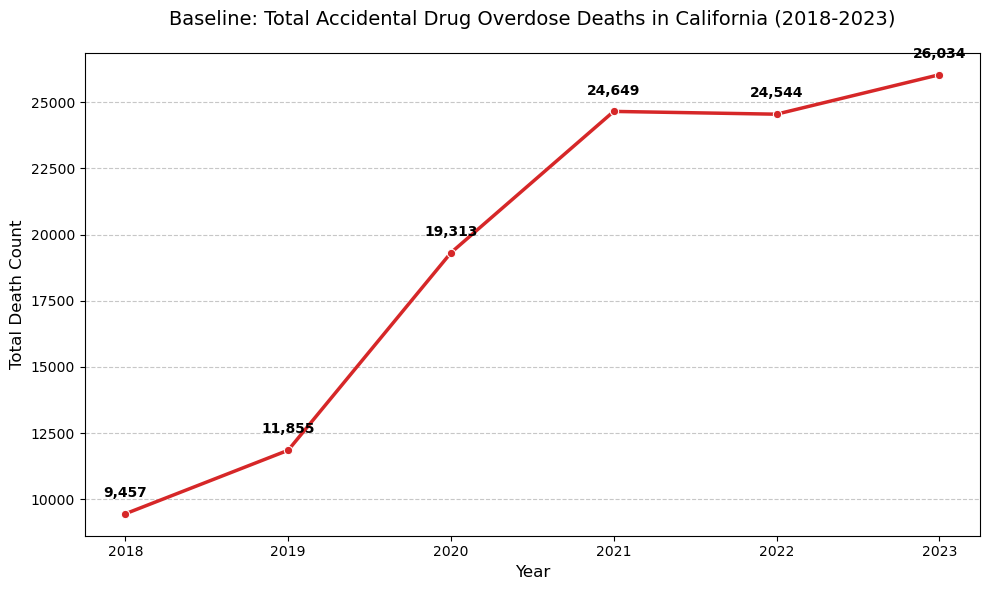

In [171]:
df_X40s['Deaths'] = pd.to_numeric(df_X40s['Deaths'], errors='coerce').fillna(0)

yearly_baseline = df_X40s.groupby('Year')['Deaths'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_baseline, x='Year', y='Deaths', marker='o', linewidth=2.5, color='#d62728')

# Add Labels and Title
plt.title('Baseline: Total Accidental Drug Overdose Deaths in California (2018-2023)', fontsize=14, pad=20)
plt.ylabel('Total Death Count', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate the values on the points
for x, y in zip(yearly_baseline['Year'], yearly_baseline['Deaths']):
    plt.text(x, y + (yearly_baseline['Deaths'].max() * 0.02), f'{int(y):,}', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [173]:
# Pivot the data to get 2018 and 2023 side-by-side per county
# Assume 'Deaths' column is already numeric and NaNs are 0
county_growth = df_X40s.pivot_table(index='County', columns='Year', values='Deaths', aggfunc='sum')
df_X40_agg = df_X40s.pivot_table(index='County', columns='Year', values='Deaths', aggfunc='sum')

#  Calculate the Percentage Change
county_growth['pct_change'] = ((county_growth[2023] - county_growth[2018]) / county_growth[2018]) * 100

hotspots = county_growth.sort_values(by='pct_change', ascending=False)

print("Top 10 Counties with Highest Overdose Growth (2018-2023):")
print(hotspots[['pct_change']].head(10))

Top 10 Counties with Highest Overdose Growth (2018-2023):
Year                         pct_change
County                                 
Santa Cruz County, CA       1433.333333
Humboldt County, CA         1041.666667
Marin County, CA             900.000000
San Luis Obispo County, CA   645.161290
Yolo County, CA              325.000000
Butte County, CA             321.621622
Alameda County, CA           298.467433
Placer County, CA            290.000000
Stanislaus County, CA        288.495575
Mendocino County, CA         280.769231


In [175]:
# Reshape df_X40_agg
df_long = df_X40_agg.reset_index()

# Melt the dataframe
# 'id_vars' are the columns you want to keep as they are
# 'var_name' will be the name of the new Year column
# 'value_name' will be the name of your deaths column
df_long = df_long.melt(
    id_vars=['County'], 
    var_name='Year', 
    value_name='total_overdose_deaths'
)

# Sort to keep counties together (optional but helpful)
df_long = df_long.sort_values(['County', 'Year']).reset_index(drop=True)
df_long

,County,Year,total_overdose_deaths
0,"Alameda County, CA",2018,261.0
1,"Alameda County, CA",2019,441.0
2,"Alameda County, CA",2020,596.0
3,"Alameda County, CA",2021,719.0
4,"Alameda County, CA",2022,829.0
...,...,...,...
271,"Yuba County, CA",2019,NaN
272,"Yuba County, CA",2020,NaN
273,"Yuba County, CA",2021,10.0
274,"Yuba County, CA",2022,61.0


**Given the 1433% increase in drug overdose death rate in Santa Cruz county and others, it is important that we remove the outliers**

In [178]:
# Isolating the Overdose pct change outliers
# Calculate the statistics for the 'pct_change' column
mean_growth = hotspots['pct_change'].mean()
std_growth = hotspots['pct_change'].std()

# Identify the 'High Growth' Outliers (1.5 standard deviations above mean)
outlier_threshold = mean_growth + (1.5 * std_growth)
hotspots['is_outlier'] = hotspots['pct_change'] > outlier_threshold

# Filter for the outliers to hand off to your team
hotspots_base = hotspots[hotspots['is_outlier'] == False].copy()

print(f"Statewide Mean Growth: {mean_growth:.2f}%")
print(f"Standard Deviation: {std_growth:.2f}%")
print(f"Outlier Threshold (>1.5 std): {outlier_threshold:.2f}%")
# print(hotspots)
print("\n--- Outlier Counties ---")
# print(economic_focus_list[['pct_change']])
hotspots[hotspots["is_outlier"] == True]

Statewide Mean Growth: 287.43%
Standard Deviation: 295.74%
Outlier Threshold (>1.5 std): 731.05%

--- Outlier Counties ---


Year,2018,2019,2020,2021,2022,2023,pct_change,is_outlier
County,,,,,,,,
"Santa Cruz County, CA",21.0,71.0,55.0,135.0,186.0,322.0,1433.333333,True
"Humboldt County, CA",12.0,24.0,40.0,118.0,173.0,137.0,1041.666667,True
"Marin County, CA",11.0,26.0,103.0,115.0,89.0,110.0,900.000000,True


In [180]:
merge_raw.head()


,county_code,county,Year,personal_income,population,per_capita_income,unemployment_rate,unemployment_count,employment_count,labor_force,total_overdose_deaths,population_od,fmr_studio,fmr_1br,fmr_2br,fmr_3br,fmr_4br
0,6001,Alameda County,2018,1.246718e+11,1680392.0,74192.0,2.92,25926,863043,888969,276.0,1666753.0,1540,1855,2329,3219,3946
1,6001,Alameda County,2019,1.346839e+11,1683879.0,79984.0,2.83,25211,864416,889627,454.0,1671329.0,1488,1808,2239,3042,3720
2,6001,Alameda County,2020,1.481991e+11,1680614.0,88182.0,8.55,72959,787361,860320,596.0,1662323.0,1658,1969,2405,3144,3706
3,6001,Alameda County,2021,1.621778e+11,1643856.0,98657.0,5.85,49595,796894,846489,719.0,1648556.0,1595,1934,2383,3196,3863
4,6001,Alameda County,2022,1.637489e+11,1635693.0,100110.0,3.20,27464,829122,856586,829.0,1628997.0,1538,1854,2274,3006,3578


In [182]:
merge_raw["total_overdose_deaths"] = df_long["total_overdose_deaths"]
print(merge_raw.head())

   county_code          county  Year  personal_income  population  \
0         6001  Alameda County  2018     1.246718e+11   1680392.0   
1         6001  Alameda County  2019     1.346839e+11   1683879.0   
2         6001  Alameda County  2020     1.481991e+11   1680614.0   
3         6001  Alameda County  2021     1.621778e+11   1643856.0   
4         6001  Alameda County  2022     1.637489e+11   1635693.0   

   per_capita_income  unemployment_rate  unemployment_count  employment_count  \
0            74192.0               2.92               25926            863043   
1            79984.0               2.83               25211            864416   
2            88182.0               8.55               72959            787361   
3            98657.0               5.85               49595            796894   
4           100110.0               3.20               27464            829122   

   labor_force  total_overdose_deaths  population_od  fmr_studio  fmr_1br  \
0       888969       

In [184]:
# Run Linear Regression for all counties across time with respoect to (labor stats/personal income/Fair Market rent)

## Ethics

### Ethics & Privacy Project Abstract
Based on our proposed question and data sets used, some ethical and privacy issues that may arise would be based on the privacy of those who are documented participating in drug abuse or have overdosed. Depending on the counties/locations we choose to study, certain biases may arise. Certain counties that are of higher economic status could result in economic data bias, which could alter how drug abuse data is documented (richer counties document fewer overdoses due to better access to medical support/rehab). Additionally, reporting bias could also be a factor, since not all drug abuse cases and overdoses are accurately represented. This is because many cases are not reported due to a lack of advanced healthcare, which is especially prevalent in rural or low-income counties with poor medical infrastructure, resulting in less accurate reports.  
  <br>
  There are important equity and privacy issues that could be problematic when analyzing data in relation to drug abuse and the economic state of a county. For instance, even though the datasets used are all publicly available and grouped by counties, there remains a risk of re-identification, particularly in counties that are sparsely populated and where overdose events are rare. In order to counter this issue, our group will ensure that the data is collected strictly at the county level, and if there are smaller counties represented, the data is aggregated with others. Additionally, correlating drug abuse with economically distressed communities may stigmatize and raise concerns within these communities. We will address these issues by making sure to use neutral and non-judgmental language and only focusing on causal claims. 


### A. Data Collection
- [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?
  <br>
  
  Most of the data used in our project will likely be information from the county level, which means individual consent may not be directly required. This includes variables such as unemployment rates, public health statistics, and other demographics. However, if any of our data sources involve surveys, interviews, or healthcare records that more explicitly identify individuals, we would take greater care to contact people so they can opt-in or opt-out as research participants that clearly understand how their data will be used. A failure in doing so would violate ethical norms or privacy, and we would also harm participants’ trust with us.
 <br>
 
- [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?
  <br> 
  
  Based on our proposed question and data sets used, some ethical and privacy issues that may arise would be based on the privacy of those who are documented participating in drug abuse or have overdosed. Depending on the counties/locations we choose to study, certain biases may arise. Certain counties that are of higher economic status could result in economic data bias, which could alter how drug abuse data is documented (richer counties document fewer overdoses due to better access to medical support/rehab). Additionally, reporting bias could also be a factor, since not all drug abuse cases and overdoses are accurately represented. This is because many cases are not reported due to a lack of advanced healthcare, which is especially prevalent in rural or low-income counties with poor medical infrastructure, resulting in less accurate reports. 
  <br>

- [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?
  <br>
  
  There are important equity and privacy issues that could be problematic when analyzing data in relation to drug abuse and the economic state of a county. For instance, even though the datasets used are all publicly available and grouped by counties, there remains a risk of re-identification, particularly in counties that are sparsely populated and where overdose events are rare. In order to counter this issue, our group will ensure that the data is collected strictly at the county level, and if there are smaller counties represented, the data is aggregated with others. Additionally, correlating drug abuse with economically distressed communities may stigmatize and raise concerns within these communities. We will address these issues by making sure to use neutral and non-judgmental language and only focusing on causal claims.  
  <br> 
- [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?
  <br>
  
  Because we are working with county or state-level data, individual demographic disparities may be avoided. At the same time, failing to consider demographic patterns could allow biased model outcomes to go unnoticed. If demographic data is included for fairness testing, it would need to be handled carefully and ethically. We recognize that including protected group data introduces its own privacy and misuse risks, but excluding it entirely may prevent us from identifying unequal impacts. Acknowledging this tension is an important part of our ethical reflection.
  <br>
### B. Data Storage
- [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
  <br>
  
  Although we are primarily using publicly available, aggregated county-level data, we still recognize the importance of responsible data storage. Even public datasets can cause harm if altered, mishandled, or combined in ways that increase sensitivity. The datasets we use would be stored on secure systems with limited access only to the team members directly involved in the project. If any dataset were to contain more granular information in the future, stronger protections such as encryption and access logging would be necessary. We acknowledge that weak data security practices could undermine trust and create preventable risks.
  <br>
- [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
  <br>
  
  Because our project uses aggregated public data and does not collect individual-level identifiers, there is no direct mechanism for individuals to request removal of personal information. However, we recognize that the original data sources we pull from may have their own policies regarding data removal or correction. If our research were to expand to include individual-level data in the future, we would need to establish a clear process allowing participants to withdraw their information. Even when not legally required, considering the right to be forgotten reflects respect for individual autonomy.
  <br>
- [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?
  <br>
  
  Since the data used in this project is publicly available and has been for a while, long-term retention may not pose a significant privacy risk. However, we acknowledge that keeping data indefinitely without purpose can create unnecessary exposure. A reasonable retention plan would involve maintaining datasets only for the duration of the research and deleting local copies once analysis and documentation are complete. Even if the risk is minimal, having a clear retention plan demonstrates intentional and responsible data stewardship on our part.
  <br>
### C. Analysis
- [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
  <br>
  
  We recognize that statistical analysis with our datasets alone cannot fully capture the lived experiences behind county-level drug abuse data. Our assumptions about economic decline and drug/substance use may overlook structural, cultural, or policy-related factors that contribute to these patterns. Without engagement from public health experts, policymakers, or even affected communities, we do risk potentially oversimplifying the issue. Even if direct engagement is not feasible for this project, we acknowledge that blind spots may exist in how we interpret and frame our findings.
  <br>
- [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?
  <br>
  
  We are aware that our hypothesis itself could introduce confirmation bias, especially since prior research or other findings can suggest a relationship to exist between unemployment and drug use. There may also be omitted confounding variables, such as healthcare access, education levels, or local policy differences, that influence drug abuse rates independently of unemployment. Additionally, some counties may have very low reported overdose rates, leading to imbalanced data that could distort model performance. Failing to account for these factors could unintentionally reinforce stereotypes or overstate causal interpretations.
  <br>
- [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?
  <br>
  
  We have a responsibility to present correlations carefully and avoid implying causation where it does not exist. Choices in visualization such as scaling, color schemes, or selective reporting of results in maps or graphs can subtly exaggerate relationships. We will be careful not to highlight only statistically significant findings while ignoring null results. Our main goal will aim to best highlight the data we’ve collected and cleaned with no other motives. Misrepresentation, even unintentionally, could contribute to public misunderstanding or policy misuse.
  <br>
- [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
  <br>
  
  Our analysis focuses on aggregated county-level data, so direct PII should not be present. However, we remain aware that combining multiple datasets can increase identifiability in smaller counties. We will avoid displaying small cell counts or granular breakdowns that could indirectly expose sensitive information. Even if the risk is minimal, protecting privacy remains a core ethical consideration.
  <br>
- [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?
  <br>

  To ensure accountability, our data cleaning steps, modeling decisions, and analytical assumptions will be clearly documented throughout the steps of our project. Without reproducibility, errors or biases could go unnoticed and uncorrected. Transparent documentation also allows others to read, critique or build upon our work responsibly. If issues are identified later, having an auditable process makes it possible to revise findings rather than defensively justify them.
  <br>
### D. Modeling
- [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
  <br>

  Since our overdose datasets are compiled at the state level, we are not working with individual demographic identifiers. However, state-level economic indicators and overdose rates may still reflect underlying inequalities. Variables such as unemployment could indirectly correlate with historically marginalized populations due to systemic disparities. Even if we are not explicitly modeling protected characteristics, we acknowledge that economic data can function as a proxy for broader social inequities. This means our model could unintentionally reinforce patterns that are rooted in structural inequality rather than individual behavior.
  <br>
- [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
  <br>
  
  Because our data is aggregated at the state level, we cannot directly test for fairness across individual demographic groups. This limits our ability to detect whether predictions would disproportionately affect certain racial, gender, or socioeconomic populations within a state. We recognize that this is a limitation of our dataset. While state-level modeling reduces individual privacy concerns, it also masks within-state disparities, which could hide unequal impacts.
  <br>
- [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
  <br>
  
  In our project, we are trying to predict state-level overdose rates using economic indicators like unemployment. How we measure model performance directly affects how we interpret our results. For example, if we only focus on overall accuracy or average error, the model might appear strong even if it does a poor job predicting overdose rates in states with the highest levels of economic distress. Since those states are central to our research question, it is important to consider whether our evaluation metric truly reflects meaningful predictive performance. We recognize that the metric we choose influences what the model prioritizes and how convincing our conclusions appear.
  <br>
- [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
  <br>
  
  If our model predicts higher overdose rates in certain states based on economic indicators, we should be able to clearly explain which variables contributed to that prediction. Since this topic involves public health and sensitive social issues, using an interpretable modeling approach is important. Overly complex models could reduce transparency and make it harder to communicate findings responsibly. We recognize that clarity and interpretability are especially important when findings could influence policy discussions.
  <br>
- [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?
  <br>
  
  Our datasets are secondary sources from Kaggle, meaning we rely on how the data was originally collected and processed. We did not control the initial data collection methods, which may introduce unknown biases or inconsistencies across states. Additionally, because the data is collected at the state level, our data analysis cannot be interpreted at the individual or county level. We acknowledge that our model identifies correlations rather than causal mechanisms, and failure to clearly communicate these limitations could lead to overgeneralization or misuse of results.
  <br>
### E. Deployment
- [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
  <br>
  
  Yes, we plan to continuously evaluate predictive performance based on appropriate statistical measures such as RMSE, MAE, and R2. Performance will also be assessed across subgroups such as county and income level to identify any potential disparities or bias with the model. We will monitor the concept drift by tracking changes in unemployment and drug abuse trends over time and make changes to it when data distributions shift significantly. 
  <br>
- [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
  <br>
  
  We will establish a formal review process in which any concerns will be addressed and taken into account when creating our model. We are aware that drug abuse can be a very difficult topic in general, and we will ensure that if any concerns come up, we will edit the model to address this. For example, we could retrain the model to omit certain data if needed, or we could adjust variable weighting, and even remove problematic proxy variables. 
  <br>
- [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
  <br>
  
  All models will be version-controlled so that the previously validated versions can be brought back quickly. If there is significant bias or harmful impacts, we will suspend outputs and replace them temporarily with descriptive statistical reporting. No fully automated decisions will be permitted, and human oversight will remain the only decision-making process. Consequently, this makes sure that the model can be safely paused or reverted while issues are investigated. 
  <br>
- [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?
  <br>
  
  There is a risk of discrimination and stigmatization during the application process because this project analyzes sensitive topics such as drug abuse and employment. However, to reduce the risj we plan to ensure that the model will only look at geographic level outputs and not individuals. By proactively identifying risks such as profiling and discriminatory use, we aim to ensure the model supports equitable public health rather than contributing to harm. 
  <br>



## Team Expectations 

**Team Expectation 1 – Communication & Meetings**
<br>Our group will maintain clear and consistent communication through a group text chat. It's expected that everyone should respond to texts within the same day (ideally within a few hours), unless they have communicated ahead of time that they will be unavailable(i.e., being sick). We will also use our scheduled discussion section time as collaborative work time and meet weekly on Mondays from 3–5 PM at Geisel library to review our invidudual progress and delegate tasks for the upcoming week. If a scheduling conflict comes up, the member will notify the group in advance. After each meeting, we will summarize what was discussed and clearly outline individual responsibilities and deadlines in the group chat so expectations remain transparent.
<br>

**Team Expectation 2 – Task Division, Contributions & Accountability**
<br>All members will contribute equally in overall effort across the entire project, including topic selection, dataset research, coding (wrangling, visualization, and analysis), writing explanations, and editing. While tasks may be divided based on individual strengths to maximize efficiency, no one person will complete an entire section alone. We will assign tasks during weekly meetings, primarily through volunteering and discussion, while ensuring workload is balanced. All responsibilities and deadlines will be documented in the group chat so progress is visible to everyone. If someone is struggling with a task, they are expected to communicate this as soon as possible so the team can redistribute work or provide support.
<br>

**Team Expectation 3 – Tone, Respect & Decision-Making**
<br>We agree to maintain a respectful, direct, and constructive tone when discussing ideas. We will use “I” statements when giving feedback (e.g., “I think this approach may not work because…”), and we will assume that all criticism is meant to improve the project. We will encourage everyone to share their opinions and ensure that quieter members have space to speak. For decisions, we will first aim for group discussion and consensus. If we cannot reach agreement in a reasonable time frame, we will use a majority vote. If further clarification is needed, we will talk with our TA.
<br>

**Team Expectation 4 – Handling Conflict & Problem Situations**
<br>If a team member is not completing agreed-upon responsibilities, we will first address the issue directly and respectfully through written communication, clearly stating what needs to be completed and by when. We will offer assistance if needed. If there is no improvement after one week, we will follow course policy and notify the professor with specific details. Our goal is to address issues early and maintain steady progress throughout the quarter.
<br>

**Team Expectation 5 – Project Planning & Organization**
<br>We will create and maintain a shared plan with deadlines for each section of the project and update it as needed throughout the quarter. Regular weekly meetings will allow us to track progress, identify challenges, and adjust our timeline if necessary. This plan will help ensure we stay on schedule and avoid last-minute work.
<br>

Throughout this project, we are committed to building a collaborative, organized, and supportive team environment where everyone contributes equally and communicates openly. 

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 2/2  |  3-5 PM | Pick 2 potential datasets each & evaluate each dataset baded on the variables and research potential  | Finalize our datasets and research question & outline and split up the proposal sections | 
| 2/4  |  5-7 PM |  Finish all the sections in the proposal based on how we divied up the workload  | Review and edit all the sections for the proposal and submit | 
| 2/9  | 3-5 PM  | Import the selected datasets, handle missing values and obvious data issues, and create summary statistics for the dataset  | Split up the project proposal feedback and make revisions on the Data Checkpoint file, determine what comparisons or relationships we will explore within our chosen datasets  |
| 2/17  | 5-7 PM  | Finish the review sections that were assigned per ech group member and push edits to the main | Refine the research question based on project proposal feedback, complete the dataset analysis and turn in our Data Checkpoint   |
| 2/23  | 3-5 PM  | Run selected statistical models and test, record the outputs and interpretations of the data | Review the results of the data collectively, troubleshoot unexpected findings, and confirm our analysis aligns with our research question |
| 2/25  |  3-4 PM |  Look through the EDA Checkpoint assignment  | Review and edit all the sections, and update to earn points back based on the TA feedback we recieved for the proposal and submit | 
| 2/26-3/2  |  flexible |  Work on adding information and data into the EDA checkpoint  | Keep each other updated of our progress via text groupchat and communicate before pushing a commit branch onto Github | 
| 3/2  | 3-5 PM  | Rerun the finalized models and clean up our code, and write clear interpretations of the results for our report | Create data visualizations, split up sections of the EDA checkpoint for each group member to work on, and verify that all our conclusions made are supported by our statistical analysis |
| 3/4  | 5-7 PM  | Finalize all the sections of our EDA Checkpoint | Review and clean up code, submit our EDA Checkpoint assignment |
| 3/9  | 3-5 PM  | Do a full code review for clarity and correctness, and double-check all calculations and outputs for the data | Finalize our presentation slides, ensure that each member is prepared to explain our projectand record our project video |
| 3/16  | 3-5 PM  | Cross-check our project with all the rubric requirements and make final edits to our project | Turn in the Final Project & complete the Group Project Surveys |